In [1]:
import xarray as xr
from PIL import Image
import tempfile
import os 
import glymur
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import convolve
from tqdm import tqdm
import pickle
import tempfile


In [2]:
plt.style.use('ggplot')

In [3]:
cmap = plt.get_cmap('viridis')

In [4]:
def get_min_max_idx(arr,axs=1, pad=True):
    grad = np.diff(arr,axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.diff(grad_sign,axis=axs) 
    min_max = np.abs(np.sign(min_max))
    if pad:
        pad_width = [(0, 0)] * arr.ndim
        pad_width[axs] = (1, 1)
        min_max = np.pad(min_max, pad_width, 'constant', constant_values=1)
    return min_max


In [5]:

def get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10):



    # Define the kernel based on the shape of the truth array
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size  # Set the size of the kernel along the specified axis
    kernel = np.ones(kernel_shape)

    # Expand the truth array with the kernel
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)

    # Compute the true positives
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)

    # Compute the false positives
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)

    # Compute the false negatives
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)

    # Compute precision and recall while avoiding division by zero
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives

    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)

    # Compute f1_score and avoid division by zero when both precision and recall are 0
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)

    return f1_score

In [6]:
data_path = "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc"

da = xr.open_dataarray(data_path)
depth_array = da.z.data
ssp_img = da.isel(time=0).data

print("Size of da in bytes:", da.nbytes)
ssp_img.shape

Size of da in bytes: 50457600000


(300, 240, 240)

In [7]:
max_depth = 2000
# Drop all lat coordinates presenting a nan for depths (z) inferior to 2000
# Select only data for depths < 2000
sub_da = da.sel(z=da.z.where(da.z < max_depth, drop=True))
# For each lat, check if there is any nan across time, z, and lon
lat_nan = sub_da.isnull().any(dim=["time", "z", "lon"])
# Get valid latitudes (i.e. where there is no nan)
valid_lats = lat_nan.where(lat_nan == False, drop=True).coords["lat"].values
# Select only the valid latitudes and drop all z coordinates superior to 2000.
da = da.sel(lat=valid_lats, z=da.z.where(da.z < max_depth, drop=True))

da_size = da.nbytes
print("Size of da in bytes:", da_size)

depth_array = da.z.data
ssp_img = da.isel(time=0).data
ssp_img.shape

Size of da in bytes: 15403584000


(157, 140, 240)

In [8]:
output_path = "/Odyssey/private/o23gauvr/input/eNATL60_BLB002_sound_speed_regrid_0_2000_no_nan.nc"
da.to_netcdf(output_path)
print(f"DataArray saved to {output_path}")

DataArray saved to /Odyssey/private/o23gauvr/input/eNATL60_BLB002_sound_speed_regrid_0_2000_no_nan.nc


In [9]:


# Normalize the data to the range 0-255 and convert to uint8
ssp_img_normalized = (255 * (ssp_img - np.nanmin(ssp_img)) / (np.nanmax(ssp_img) - np.nanmin(ssp_img))).astype(np.uint8)

# # Create an image from the normalized array
# image = Image.fromarray(ssp_img_normalized[0])  # Select the first slice if it's a 3D array
# image

In [10]:
# with tempfile.TemporaryDirectory() as tmpdir:
#     frame_files = []
#     for i in range(ssp_img_normalized.shape[0]):
#         frame_path = os.path.join(tmpdir, f"frame_{i:03d}.png")
#         # Each channel is a 2D grayscale image.
#         img = Image.fromarray(ssp_img_normalized[i])
#         img.save(frame_path)
#         frame_files.append(frame_path)
    
#     # Name of the output JPEG XL file
#     output_filename = "hyperspectral_animation.jxl"
    
#     # Build the cjxl command:
#     # The command-line tool accepts multiple input files to create an animation.
#     # Example: cjxl frame_000.png frame_001.png ... output.jxl
#     cmd = ["cjxl"] + frame_files + [output_filename]
    
#     # Run the command. Check for errors as needed.
#     subprocess.run(cmd, check=True)

# print("JPEG XL multi-frame image created as:", output_filename)

In [11]:
transposed_ssp_img = ssp_img_normalized.transpose(1, 2, 0)
# Specify the output JPEG2000 filename.
output_filename = 'hyperspectral.jp2'

# Write the JPEG2000 image using glymur.
jp2 = glymur.Jp2k(output_filename, data=transposed_ssp_img)

print("JPEG2000 image saved as:", output_filename)

InvalidJp2kError: A valid JP2C box was not found in the outermost level of JP2 boxes.  The JP2 file is invalid.

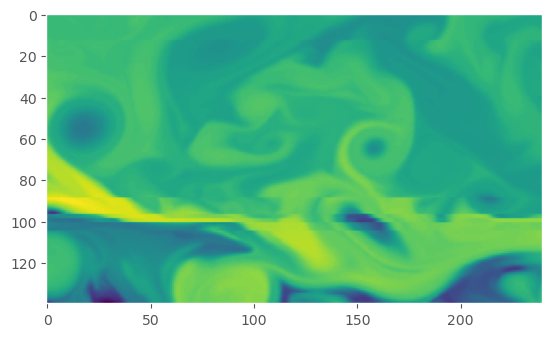

In [ ]:
plt.imshow(jp2[...,0])
plt.grid(False)
plt.show()

In [12]:
def glymur_encode(img, quality=10):
    # Mapping: quality=100 means low compression (ratio=1), quality=0 means high compression (ratio increases)
    # Adjust the mapping as needed.
    ratio = 1 + (100 - quality) / 10.0  # e.g. quality=100 -> ratio=1, quality=0 -> ratio=11

    # Write the JPEG2000 image to a temporary file.
    with tempfile.NamedTemporaryFile(suffix=".jp2", delete=False) as tmp:
        tmp_name = tmp.name

    # Create JPEG2000 file using glymur with the computed compression ratio.
    jp2 = glymur.Jp2k(tmp_name, data=img, cratios=[ratio])
    
    # Compute file size.
    filesize = os.stat(tmp_name).st_size

    # Assuming the image is a numpy array with shape (height, width, channels)
    height, width = img.shape[0], img.shape[1]
    bpp = filesize * 8 / (width * height)
    
    # Read back the compressed image.
    rec = glymur.Jp2k(tmp_name).read()

    # Remove the temporary file.
    os.remove(tmp_name)
    return rec, bpp



def find_closest_bpp(target, img):
    lower = 0
    upper = 100
    prev_mid = upper
    for i in range(10):
        mid = (upper - lower) / 2 + lower
        # Break if mid quality doesn't change.
        if int(mid) == int(prev_mid):
            break
        rec, bpp = glymur_encode(img, quality=int(mid))
        if bpp > target:
            upper = mid - 1
        else:
            lower = mid
        prev_mid = mid
    return rec, bpp

In [13]:
ratios = np.logspace(-1, 6, num=10)
for ratio in ratios:
    with tempfile.TemporaryDirectory() as tmpdirname:
        output_filename = os.path.join(tmpdirname, 'hyperspectral.jp2')
        try:
            glymur.Jp2k(output_filename, data=transposed_ssp_img, cratios=[ratio])
        except:
            print("Error with ratio:", ratio)
            break
        

        filesize = os.stat(output_filename).st_size

        # Assuming the image is a numpy array with shape (height, width, channels)
        height, width = transposed_ssp_img.shape[0], transposed_ssp_img.shape[1]

        bpp = filesize * 8 / (width * height)

        # Read back the compressed image.
        rec = glymur.Jp2k(output_filename).read()

    print("Size of compressed image in bytes:", filesize)


Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006717
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of compressed image in bytes: 1006751
Size of com

In [14]:
bpp

0.38952380952380955

### In this code i get bpp=218, is it coherent with quality=0.2 ?



The value you obtain isn't inherently wrong—it simply reflects how the chosen mapping from "quality" to the compression ratio interacts with your specific image data. In the code:

  ratio = 1 + (100 - quality) / 10.0

with quality = 0.2 gives you a ratio of approximately 10.98. This high ratio can lead to a compressed file that, when measured over the whole hyperspectral data (which may have many channels and high bit depth), results in around 218 bits per pixel.

Keep in mind that:

The "quality" parameter here isn't a standard JPEG2000 quality metric—it’s just a value you map to a compression ratio.
Hyperspectral images can be very large and have many channels, so bpp values may be much higher than the typical 24 or 32 bpp seen with conventional images.
If you want a specific target bpp, you might need to adjust your mapping function or perform iterative searches (as in your earlier binary search function).
So, while 218 bpp may seem high compared to standard color images, it can be coherent for hyperspectral data given the parameters used.

In [15]:
rec.shape

(140, 240, 157)

In [16]:
ssp_img_reversed = (rec.astype(float) / 255) * (np.nanmax(ssp_img) - np.nanmin(ssp_img)) + np.nanmin(ssp_img)
print(ssp_img_reversed.mean())

1511.1471628390896


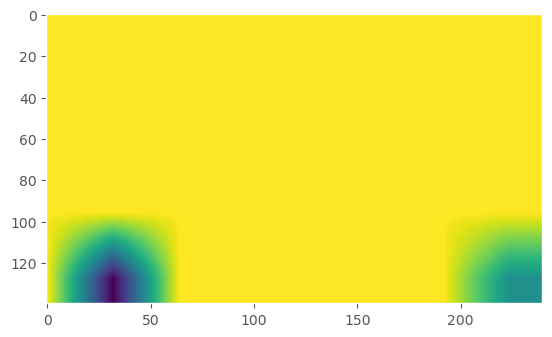

In [17]:
plt.imshow(ssp_img_reversed[...,0])
plt.grid(False)

In [18]:
ssp_img_reversed = ssp_img_reversed.transpose(2, 0, 1)
ssp_img_reversed.shape

(157, 140, 240)

In [19]:
rmse = np.sqrt(np.nanmean((ssp_img - ssp_img_reversed) ** 2))
print("RMSE:", rmse)

RMSE: 15.746246201870509


In [20]:
ssp_img_reversed.mean()

1511.1471628390896

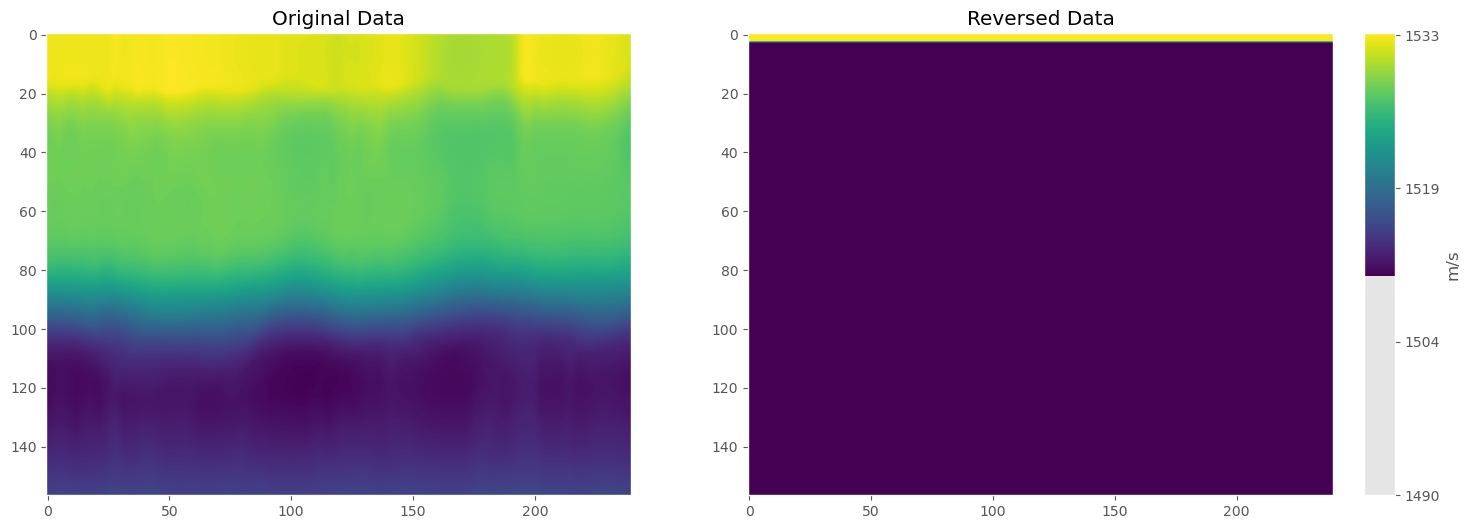

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot the original data
im1 = axes[0].imshow(ssp_img[:, 0, :], aspect='auto')
axes[0].set_title('Original Data')
axes[0].grid(False)

# Plot the reversed data
im2 = axes[1].imshow(ssp_img_reversed[:, 0, :], aspect='auto')
axes[1].set_title('Reversed Data')
axes[1].grid(False)

# Add a single colorbar on the right
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink = 1, aspect=15, pad = 0.02)
cbar.set_label("m/s")

min_val, max_val = im1.get_clim()
ticks = np.linspace(min_val, max_val, 4)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in ticks])
#plt.tight_layout()
plt.show()

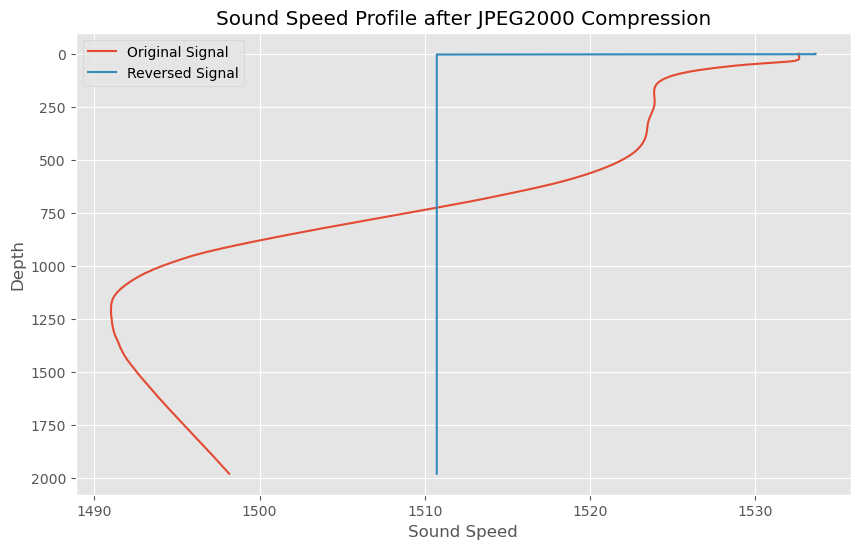

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(ssp_img[:, 0, 0], depth_array, label='Original Signal')
plt.plot(ssp_img_reversed[:, 0, 0], depth_array, label='Reversed Signal')
plt.gca().invert_yaxis()
plt.xlabel('Sound Speed')
plt.ylabel('Depth')
plt.title('Sound Speed Profile after JPEG2000 Compression')
plt.legend()
plt.show()

In [23]:
full_img = da.data
# full_img = (255 * (full_img - np.nanmin(full_img)) / (np.nanmax(full_img) - np.nanmin(full_img))).astype(np.uint8)
# full_img = full_img.transpose(0,2, 3, 1)

print(full_img.shape)

(365, 157, 140, 240)


Ratios:   0%|          | 0/6 [00:00<?, ?it/s]

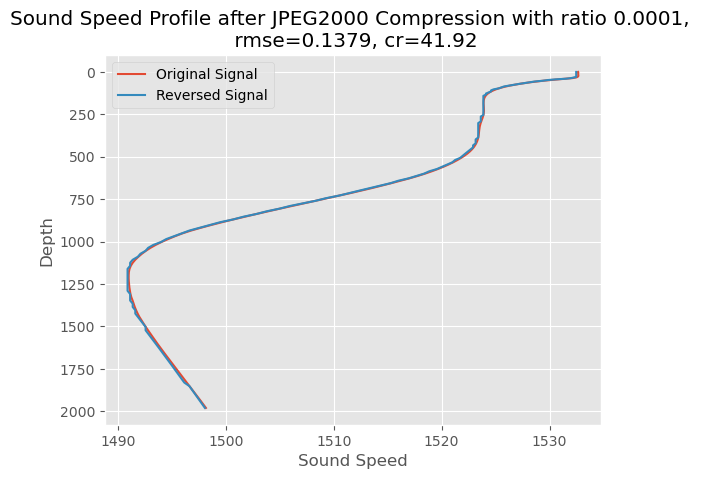

Ratios:  17%|█▋        | 1/6 [00:09<00:46,  9.36s/it]

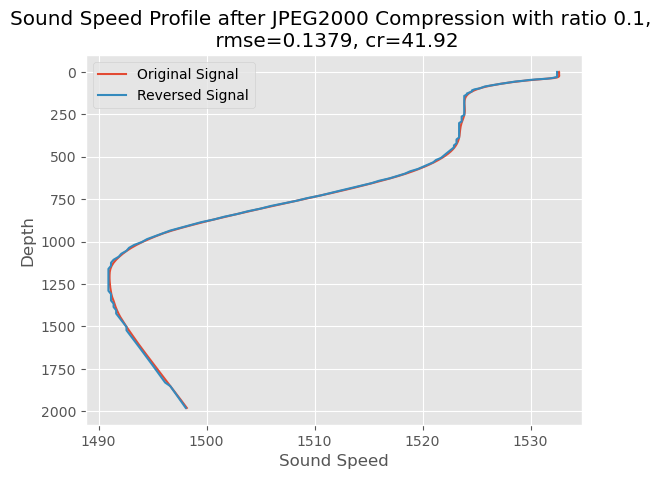

Ratios:  33%|███▎      | 2/6 [00:18<00:37,  9.31s/it]

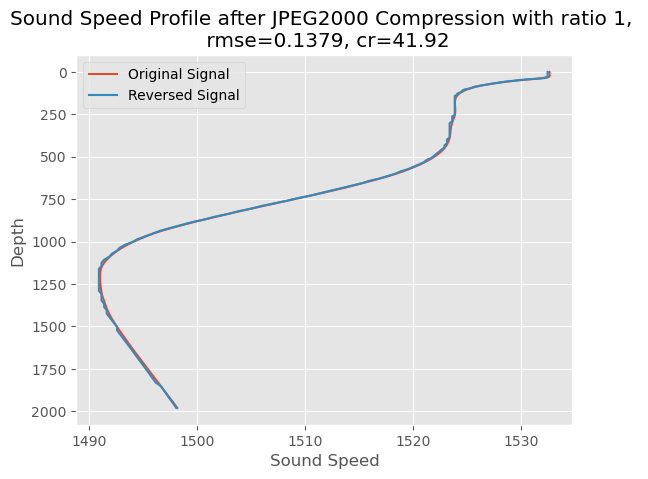

Ratios:  50%|█████     | 3/6 [00:27<00:27,  9.26s/it]

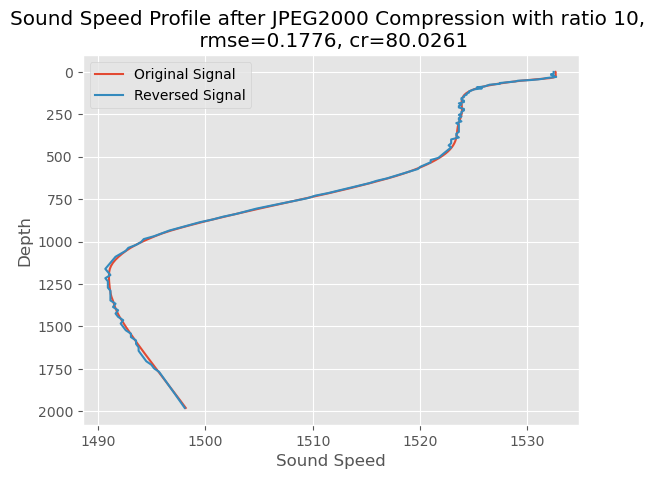

Ratios:  67%|██████▋   | 4/6 [00:36<00:18,  9.21s/it]

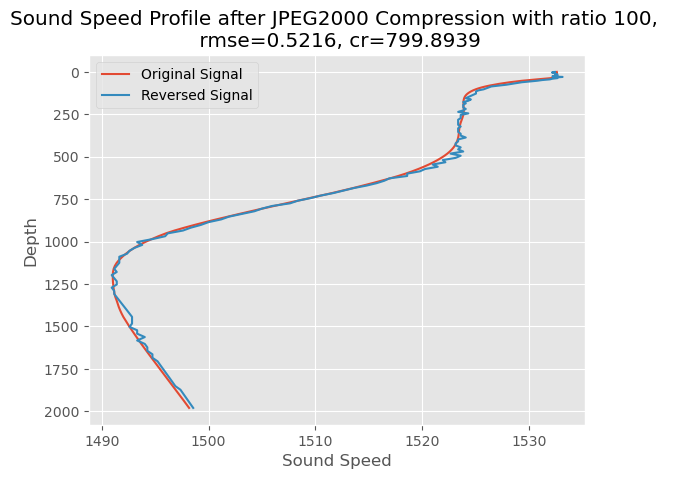

Ratios:  83%|████████▎ | 5/6 [00:46<00:09,  9.47s/it]

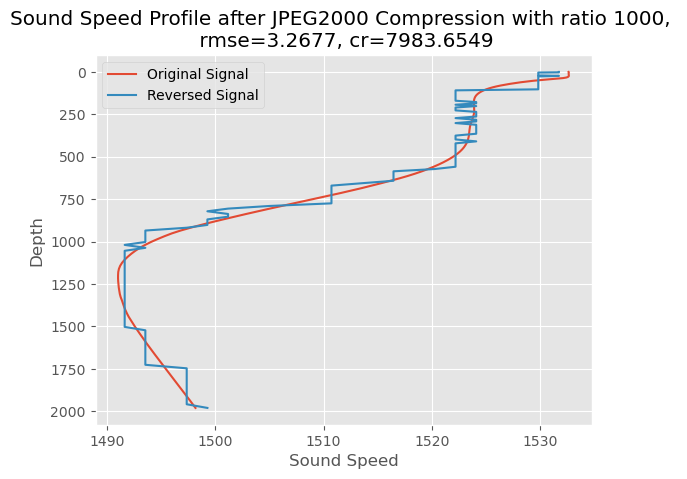

Ratios: 100%|██████████| 6/6 [00:55<00:00,  9.33s/it]


In [34]:
ratios = [0.0001,0.1,1,10,100,1000]#np.logspace(-1, 6, num=100)

min_max_idx_truth = get_min_max_idx(full_img,axs=1, pad=False)
ecs_truth_idx = np.argmax(full_img,axis=1)
ecs_truth = depth_array[ecs_truth_idx]

rmse_dict = {"SSP":{},
             "ECS":{},
             "mean_error_n_min_max":{},
             "F1_score":{},
             "cr":{}}

for ratio in tqdm(ratios, desc="Ratios"):

    image_size = 0
    decompressed_img = np.zeros(full_img.shape)



    for img_idx in tqdm(range(1), desc="Images"):

        img = full_img[img_idx]

        nan_min = np.nanmin(img)
        nan_max = np.nanmax(img)
        
        img = (255 * (img - nan_min) / (nan_max - nan_min)).astype(np.uint8)
        img = img.transpose(1, 2, 0)


        with tempfile.TemporaryDirectory() as tmpdirname:
            output_filename = os.path.join(tmpdirname, 'hyperspectral.jp2')
            #output_filename = 'hyperspectral.jp2'
            glymur.Jp2k(output_filename, data=img, cratios=[ratio])

            image_size = image_size + os.stat(output_filename).st_size

            # # Assuming the image is a numpy array with shape (height, width, channels)
            # height, width = transposed_ssp_img.shape[0], transposed_ssp_img.shape[1]
            # bpp = filesize * 8 / (width * height)

            # Read back the compressed image.
            rec = glymur.Jp2k(output_filename).read()
            compressed_size = os.stat(output_filename).st_size


        uncompressed_img = (rec.astype(float) / 255) * (nan_max - nan_min) + nan_min
        uncompressed_img = uncompressed_img.transpose(2, 0, 1)

        rmse = np.sqrt(np.nanmean((full_img[img_idx] - uncompressed_img) ** 2))

        truth_size = full_img[img_idx].nbytes
        cr = truth_size / compressed_size

        plt.plot(full_img[img_idx,:,0,0],depth_array, label='Original Signal')
        plt.plot(uncompressed_img[:,0,0],depth_array, label='Reversed Signal')
        plt.gca().invert_yaxis()
        plt.xlabel('Sound Speed')
        plt.ylabel('Depth')
        plt.title(f'Sound Speed Profile after JPEG2000 Compression with ratio {ratio}, \n rmse={np.round(rmse,4)}, cr={np.round(cr,4)}')
        plt.legend()
        plt.show()

        #decompressed_img[img_idx] = uncompressed_img


    rmse = np.sqrt(np.nanmean((full_img - decompressed_img) ** 2))

    # ecs_decompressed_idx = np.argmax(decompressed_img,axis=1)
    # ecs_decompressed = depth_array[ecs_decompressed_idx]

    # ecs_rmse = np.sqrt(np.nanmean((ecs_truth - ecs_decompressed) ** 2))

    # min_max_idx_decompressed = get_min_max_idx(decompressed_img, axs=1, pad=False)

    # mean_error_n_min_max = np.mean(np.abs(min_max_idx_truth - min_max_idx_decompressed))

    # F1_score = get_f1_score(min_max_idx_truth, min_max_idx_decompressed, axs=1, kernel_size=10)
    # f1_score = np.mean(F1_score)
    
    cr = da_size / image_size


    rmse_dict["SSP"][f"compression ratio {ratio}"] = rmse
    #rmse_dict["ECS"][f"compression ratio {ratio}"] = ecs_rmse
    # rmse_dict["mean_error_n_min_max"][f"compression ratio {ratio}"] = mean_error_n_min_max
    # rmse_dict["F1_score"][f"compression ratio {ratio}"] = f1_score
    # rmse_dict["cr"][f"compression ratio {ratio}"] = cr

    


# with open(f'pickle/rmse_jpeg_2000.pkl', 'wb') as f:
#     pickle.dump(rmse_dict, f)

    

In [28]:
full_img[img_idx,:,0,0].shape

(157,)